<a href="https://colab.research.google.com/github/minhasaleem/MechMedic---RandomForest-Model/blob/main/AI4I_2020_Predictive_Maintenance_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# =========================================================
# STEP 1: UPLOAD AND EXTRACT DATASET
# =========================================================

from google.colab import files
import zipfile
import os

# Upload the ZIP file
uploaded = files.upload()

zip_file = "try.zip"

# Folder for extracted files
extract_path = "/content/random_forest_dataset"

os.makedirs(extract_path, exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

print("\nFiles available:")
for root, dirs, files_in_folder in os.walk(extract_path):
    for file_name in files_in_folder:
        print(os.path.join(root, file_name))

Saving try.zip to try.zip
Dataset extracted successfully!

Files available:
/content/random_forest_dataset/predictive_maintenance.csv


In [4]:
# =========================================================
# STEP 2: LOAD AND INSPECT THE DATASET
# =========================================================

import pandas as pd
import os


# ---------------------------------------------------------
# 1. Define dataset path
# ---------------------------------------------------------

file_path = os.path.join(
    extract_path,
    "predictive_maintenance.csv"
)


# ---------------------------------------------------------
# 2. Load the CSV file
# ---------------------------------------------------------

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")


# ---------------------------------------------------------
# 3. Display dataset shape
# ---------------------------------------------------------

print("\nDataset shape:")
print(df.shape)


# ---------------------------------------------------------
# 4. Display column names
# ---------------------------------------------------------

print("\nColumn names:")
print(df.columns.tolist())


# ---------------------------------------------------------
# 5. Display first 5 rows
# ---------------------------------------------------------

print("\nFirst 5 rows:")
display(df.head())


# ---------------------------------------------------------
# 6. Check data types
# ---------------------------------------------------------

print("\nData types:")
print(df.dtypes)


# ---------------------------------------------------------
# 7. Check missing values
# ---------------------------------------------------------

print("\nMissing values:")
print(df.isnull().sum())


# ---------------------------------------------------------
# 8. Check duplicate rows
# ---------------------------------------------------------

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


# ---------------------------------------------------------
# 9. Display basic statistical information
# ---------------------------------------------------------

print("\nStatistical summary:")
display(df.describe())

Dataset loaded successfully!

Dataset shape:
(10000, 10)

Column names:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type']

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure



Data types:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                object
dtype: object

Missing values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

Number of duplicate rows:
0

Statistical summary:


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [5]:
# =========================================================
# STEP 3: INSPECT FAILURE TYPE DISTRIBUTION
# =========================================================


# ---------------------------------------------------------
# 1. Count each failure type
# ---------------------------------------------------------

failure_counts = df["Failure Type"].value_counts()

print("Failure Type distribution:")
print(failure_counts)


# ---------------------------------------------------------
# 2. Calculate percentage of each failure type
# ---------------------------------------------------------

failure_percentages = (
    df["Failure Type"]
    .value_counts(normalize=True)
    * 100
)

print("\nFailure Type percentages:")
print(failure_percentages.round(2))


# ---------------------------------------------------------
# 3. Check binary Target distribution
# ---------------------------------------------------------

print("\nBinary Target distribution:")
print(df["Target"].value_counts())

print("\nBinary Target percentages:")
print(
    (
        df["Target"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)


# ---------------------------------------------------------
# 4. Check relationship between Target and Failure Type
# ---------------------------------------------------------

print("\nTarget vs Failure Type:")
print(
    pd.crosstab(
        df["Failure Type"],
        df["Target"]
    )
)

Failure Type distribution:
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

Failure Type percentages:
Failure Type
No Failure                  96.52
Heat Dissipation Failure     1.12
Power Failure                0.95
Overstrain Failure           0.78
Tool Wear Failure            0.45
Random Failures              0.18
Name: proportion, dtype: float64

Binary Target distribution:
Target
0    9661
1     339
Name: count, dtype: int64

Binary Target percentages:
Target
0    96.61
1     3.39
Name: proportion, dtype: float64

Target vs Failure Type:
Target                       0    1
Failure Type                       
Heat Dissipation Failure     0  112
No Failure                9643    9
Overstrain Failure           0   78
Power Failure                0   95
Random Failures             18    0
Tool Wear 

In [6]:
# =========================================================
# STEP 4: PREPARE FEATURES AND TARGET
# =========================================================

import pandas as pd


# ---------------------------------------------------------
# 1. Create input features
# ---------------------------------------------------------

X = df[
    [
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ]
].copy()


# ---------------------------------------------------------
# 2. Create target
# ---------------------------------------------------------

y = df["Failure Type"].copy()


# ---------------------------------------------------------
# 3. Encode machine Type
# ---------------------------------------------------------

X = pd.get_dummies(
    X,
    columns=["Type"],
    drop_first=False,
    dtype=int
)


# ---------------------------------------------------------
# 4. Display prepared data
# ---------------------------------------------------------

print("Features and target prepared successfully!")

print("\nX shape:")
print(X.shape)

print("\ny shape:")
print(y.shape)

print("\nInput columns:")
print(X.columns.tolist())

print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 target values:")
print(y.head())

Features and target prepared successfully!

X shape:
(10000, 8)

y shape:
(10000,)

Input columns:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_H', 'Type_L', 'Type_M']

First 5 rows of X:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,1,0
2,298.1,308.5,1498,49.4,5,0,1,0
3,298.2,308.6,1433,39.5,7,0,1,0
4,298.2,308.7,1408,40.0,9,0,1,0



First 5 target values:
0    No Failure
1    No Failure
2    No Failure
3    No Failure
4    No Failure
Name: Failure Type, dtype: object


In [7]:
# =========================================================
# STEP 5: STRATIFIED TRAIN / TEST SPLIT
# =========================================================

from sklearn.model_selection import train_test_split


# ---------------------------------------------------------
# 1. Split dataset
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ---------------------------------------------------------
# 2. Display dataset sizes
# ---------------------------------------------------------

print("Train/test split completed successfully!")

print("\nTotal samples:", len(X))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# 3. Training class distribution
# ---------------------------------------------------------

print("\nTraining class distribution:")
print(y_train.value_counts())


# ---------------------------------------------------------
# 4. Testing class distribution
# ---------------------------------------------------------

print("\nTesting class distribution:")
print(y_test.value_counts())


# ---------------------------------------------------------
# 5. Testing class percentages
# ---------------------------------------------------------

print("\nTesting class percentages:")
print(
    (
        y_test.value_counts(normalize=True)
        * 100
    ).round(2)
)

Train/test split completed successfully!

Total samples: 10000
Training samples: 8000
Testing samples: 2000

Training class distribution:
Failure Type
No Failure                  7722
Heat Dissipation Failure      90
Power Failure                 76
Overstrain Failure            62
Tool Wear Failure             36
Random Failures               14
Name: count, dtype: int64

Testing class distribution:
Failure Type
No Failure                  1930
Heat Dissipation Failure      22
Power Failure                 19
Overstrain Failure            16
Tool Wear Failure              9
Random Failures                4
Name: count, dtype: int64

Testing class percentages:
Failure Type
No Failure                  96.50
Heat Dissipation Failure     1.10
Power Failure                0.95
Overstrain Failure           0.80
Tool Wear Failure            0.45
Random Failures              0.20
Name: proportion, dtype: float64


In [8]:
# =========================================================
# STEP 6: BUILD AND TRAIN BASELINE RANDOM FOREST
# =========================================================

from sklearn.ensemble import RandomForestClassifier


# ---------------------------------------------------------
# 1. Create Random Forest model
# ---------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


# ---------------------------------------------------------
# 2. Train the model
# ---------------------------------------------------------

rf_model.fit(
    X_train,
    y_train
)


print("Random Forest model trained successfully!")

print("\nNumber of trees:")
print(rf_model.n_estimators)

print("\nNumber of input features:")
print(rf_model.n_features_in_)

print("\nClasses learned by the model:")
print(rf_model.classes_)

Random Forest model trained successfully!

Number of trees:
200

Number of input features:
8

Classes learned by the model:
['Heat Dissipation Failure' 'No Failure' 'Overstrain Failure'
 'Power Failure' 'Random Failures' 'Tool Wear Failure']


In [9]:
# =========================================================
# STEP 7: EVALUATE RANDOM FOREST MODEL
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ---------------------------------------------------------
# 1. Make predictions on test data
# ---------------------------------------------------------

y_pred = rf_model.predict(X_test)


# ---------------------------------------------------------
# 2. Calculate accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Test Accuracy:")
print(f"{accuracy * 100:.2f}%")


# ---------------------------------------------------------
# 3. Classification report
# ---------------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ---------------------------------------------------------
# 4. Confusion matrix
# ---------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=rf_model.classes_
)

print("\nConfusion Matrix:")
print(cm)

Random Forest Test Accuracy:
97.85%

Classification Report:
                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      0.45      0.62        22
              No Failure       0.98      1.00      0.99      1930
      Overstrain Failure       1.00      0.56      0.72        16
           Power Failure       1.00      0.42      0.59        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.98      2000
               macro avg       0.66      0.41      0.49      2000
            weighted avg       0.97      0.98      0.97      2000


Confusion Matrix:
[[  10   12    0    0    0    0]
 [   0 1930    0    0    0    0]
 [   0    7    9    0    0    0]
 [   0   11    0    8    0    0]
 [   0    4    0    0    0    0]
 [   0    9    0    0    0    0]]


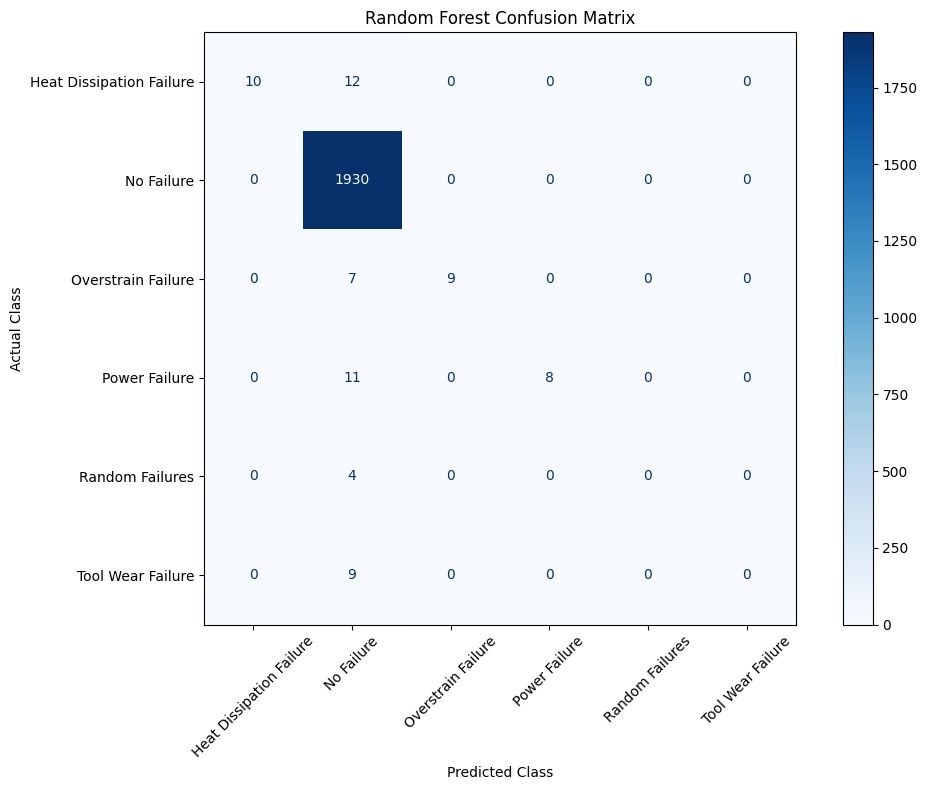

In [10]:
# =========================================================
# STEP 8: VISUALIZE CONFUSION MATRIX
# =========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


# ---------------------------------------------------------
# 1. Create confusion matrix display
# ---------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)


# ---------------------------------------------------------
# 2. Plot confusion matrix
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

Random Forest Feature Importance:


,Feature,Importance
4,Tool wear [min],0.259753
3,Torque [Nm],0.244726
2,Rotational speed [rpm],0.208877
0,Air temperature [K],0.136854
1,Process temperature [K],0.110465
6,Type_L,0.017960
7,Type_M,0.013940
5,Type_H,0.007425


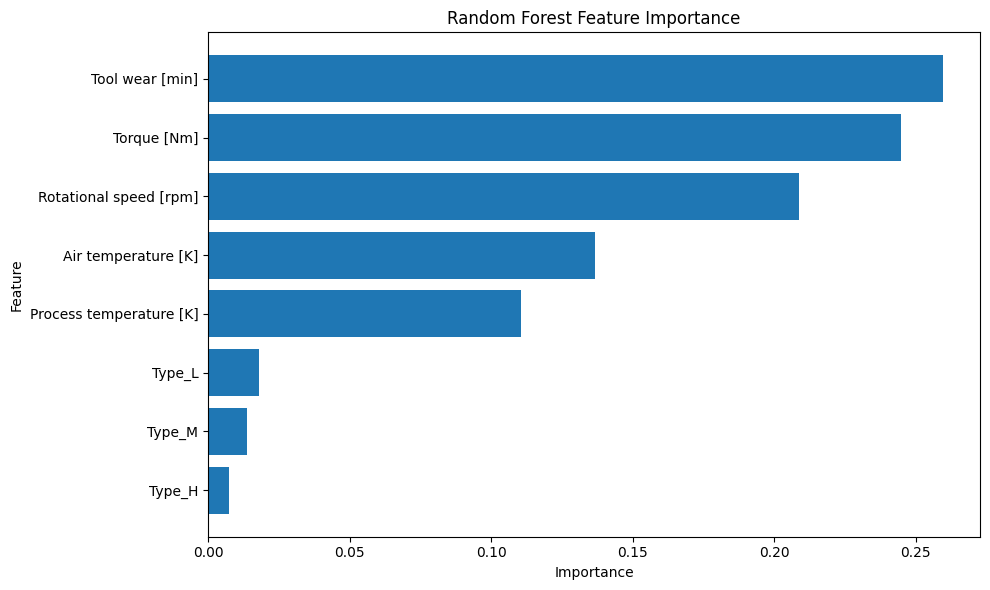

In [11]:
# =========================================================
# STEP 9: FEATURE IMPORTANCE
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Get feature importance values
# ---------------------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})


# ---------------------------------------------------------
# 2. Sort from highest to lowest importance
# ---------------------------------------------------------

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


# ---------------------------------------------------------
# 3. Display values
# ---------------------------------------------------------

print("Random Forest Feature Importance:")
display(feature_importance)


# ---------------------------------------------------------
# 4. Plot feature importance
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [12]:
# =========================================================
# STEP 10: 5-FOLD STRATIFIED CROSS-VALIDATION
# =========================================================

import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier


# ---------------------------------------------------------
# 1. Create model for cross-validation
# ---------------------------------------------------------

rf_cv = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


# ---------------------------------------------------------
# 2. Define stratified 5-fold cross-validation
# ---------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ---------------------------------------------------------
# 3. Metrics to evaluate
# ---------------------------------------------------------

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}


# ---------------------------------------------------------
# 4. Perform cross-validation
# ---------------------------------------------------------

cv_results = cross_validate(
    rf_cv,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)


# ---------------------------------------------------------
# 5. Display each fold
# ---------------------------------------------------------

for i in range(5):
    print(f"\nFold {i + 1}")
    print(f"Accuracy : {cv_results['test_accuracy'][i] * 100:.2f}%")
    print(f"Precision: {cv_results['test_precision'][i] * 100:.2f}%")
    print(f"Recall   : {cv_results['test_recall'][i] * 100:.2f}%")
    print(f"F1-score : {cv_results['test_f1'][i] * 100:.2f}%")


# ---------------------------------------------------------
# 6. Display average performance
# ---------------------------------------------------------

print("\n==============================")
print("AVERAGE CROSS-VALIDATION RESULTS")
print("==============================")

print(
    f"Accuracy : "
    f"{np.mean(cv_results['test_accuracy']) * 100:.2f}%"
)

print(
    f"Precision: "
    f"{np.mean(cv_results['test_precision']) * 100:.2f}%"
)

print(
    f"Recall   : "
    f"{np.mean(cv_results['test_recall']) * 100:.2f}%"
)

print(
    f"F1-score : "
    f"{np.mean(cv_results['test_f1']) * 100:.2f}%"
)

print(
    f"Accuracy Standard Deviation: "
    f"{np.std(cv_results['test_accuracy']) * 100:.2f}%"
)


Fold 1
Accuracy : 97.75%
Precision: 62.37%
Recall   : 39.03%
F1-score : 46.56%

Fold 2
Accuracy : 98.00%
Precision: 58.53%
Recall   : 43.57%
F1-score : 49.27%

Fold 3
Accuracy : 97.75%
Precision: 63.51%
Recall   : 38.93%
F1-score : 45.75%

Fold 4
Accuracy : 97.70%
Precision: 62.14%
Recall   : 39.80%
F1-score : 47.08%

Fold 5
Accuracy : 97.70%
Precision: 63.10%
Recall   : 38.14%
F1-score : 45.33%

AVERAGE CROSS-VALIDATION RESULTS
Accuracy : 97.78%
Precision: 61.93%
Recall   : 39.89%
F1-score : 46.80%
Accuracy Standard Deviation: 0.11%


In [13]:
# =========================================================
# STEP 11: RANDOM FOREST HYPERPARAMETER TUNING
# =========================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


# ---------------------------------------------------------
# 1. Create base Random Forest
# ---------------------------------------------------------

rf_base = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)


# ---------------------------------------------------------
# 2. Define parameters to test
# ---------------------------------------------------------

param_grid = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [None, 5, 10, 15, 20],

    "min_samples_split": [2, 4, 6, 10],

    "min_samples_leaf": [1, 2, 4, 6],

    "max_features": ["sqrt", "log2", None],

    "criterion": ["gini", "entropy"],

    "bootstrap": [True, False]
}


# ---------------------------------------------------------
# 3. Stratified cross-validation
# ---------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ---------------------------------------------------------
# 4. Randomized search
# ---------------------------------------------------------

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=30,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


# ---------------------------------------------------------
# 5. Perform tuning
# ---------------------------------------------------------

random_search.fit(X_train, y_train)


# ---------------------------------------------------------
# 6. Get best model
# ---------------------------------------------------------

rf_tuned = random_search.best_estimator_


# ---------------------------------------------------------
# 7. Display results
# ---------------------------------------------------------

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation Macro F1:")
print(f"{random_search.best_score_ * 100:.2f}%")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10, 'criterion': 'entropy', 'bootstrap': True}

Best Cross-Validation Macro F1:
58.10%


In [14]:
# =========================================================
# STEP 12: EVALUATE TUNED RANDOM FOREST
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ---------------------------------------------------------
# 1. Predict test data using tuned model
# ---------------------------------------------------------

y_pred_tuned = rf_tuned.predict(X_test)


# ---------------------------------------------------------
# 2. Calculate accuracy
# ---------------------------------------------------------

tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

print("Tuned Random Forest Test Accuracy:")
print(f"{tuned_accuracy * 100:.2f}%")


# ---------------------------------------------------------
# 3. Classification report
# ---------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_tuned,
        zero_division=0
    )
)


# ---------------------------------------------------------
# 4. Confusion matrix
# ---------------------------------------------------------

cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned,
    labels=rf_tuned.classes_
)

print("\nConfusion Matrix:")
print(cm_tuned)

Tuned Random Forest Test Accuracy:
96.25%

Classification Report:
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.91      0.95      0.93        22
              No Failure       0.99      0.97      0.98      1930
      Overstrain Failure       0.69      0.69      0.69        16
           Power Failure       0.93      0.74      0.82        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.04      0.22      0.07         9

                accuracy                           0.96      2000
               macro avg       0.59      0.60      0.58      2000
            weighted avg       0.98      0.96      0.97      2000


Confusion Matrix:
[[  21    1    0    0    0    0]
 [   2 1877    3    1    2   45]
 [   0    5   11    0    0    0]
 [   0    4    1   14    0    0]
 [   0    4    0    0    0    0]
 [   0    6    1    0    0    2]]


In [15]:
# =========================================================
# STEP 13: CROSS-VALIDATION OF TUNED RANDOM FOREST
# =========================================================

import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier


# Create tuned Random Forest
rf_tuned_cv = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=6,
    min_samples_leaf=1,
    max_features=None,
    max_depth=10,
    criterion="entropy",
    bootstrap=True,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


# Stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Evaluation metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}


# Run cross-validation
cv_tuned = cross_validate(
    rf_tuned_cv,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)


# Display individual folds
for i in range(5):

    print(f"\nFold {i + 1}")

    print(
        f"Accuracy : "
        f"{cv_tuned['test_accuracy'][i] * 100:.2f}%"
    )

    print(
        f"Precision: "
        f"{cv_tuned['test_precision'][i] * 100:.2f}%"
    )

    print(
        f"Recall   : "
        f"{cv_tuned['test_recall'][i] * 100:.2f}%"
    )

    print(
        f"F1-score : "
        f"{cv_tuned['test_f1'][i] * 100:.2f}%"
    )


# Average results
print("\n==============================")
print("TUNED CROSS-VALIDATION RESULTS")
print("==============================")

print(
    f"Accuracy : "
    f"{np.mean(cv_tuned['test_accuracy']) * 100:.2f}%"
)

print(
    f"Precision: "
    f"{np.mean(cv_tuned['test_precision']) * 100:.2f}%"
)

print(
    f"Recall   : "
    f"{np.mean(cv_tuned['test_recall']) * 100:.2f}%"
)

print(
    f"F1-score : "
    f"{np.mean(cv_tuned['test_f1']) * 100:.2f}%"
)

print(
    f"Accuracy Standard Deviation: "
    f"{np.std(cv_tuned['test_accuracy']) * 100:.2f}%"
)


Fold 1
Accuracy : 95.50%
Precision: 58.18%
Recall   : 57.81%
F1-score : 56.00%

Fold 2
Accuracy : 95.65%
Precision: 54.74%
Recall   : 59.41%
F1-score : 55.27%

Fold 3
Accuracy : 95.40%
Precision: 56.82%
Recall   : 59.48%
F1-score : 56.48%

Fold 4
Accuracy : 95.50%
Precision: 59.34%
Recall   : 70.08%
F1-score : 60.82%

Fold 5
Accuracy : 95.60%
Precision: 60.49%
Recall   : 61.73%
F1-score : 58.49%

TUNED CROSS-VALIDATION RESULTS
Accuracy : 95.53%
Precision: 57.91%
Recall   : 61.70%
F1-score : 57.41%
Accuracy Standard Deviation: 0.09%
